# Access WOC Total Surface Current at 15 m

[Explore Data](https://sunnydean.github.io/ocean_cubes_vis/?cube=https%3A%2F%2Fs3.waw4-1.cloudferro.com%2FEarthCODE%2FOSCAssets%2Fmed_cubes%2Fhourly_cube.zarr&variable=ut_woc)

    * Original Data Source: https://www.worldoceancirculation.org/Products#/metadata/b72f4ac1-ffc6-4ba9-a729-670b6e879d52
    * Reference:  https://doi.org/10.25423/cmcc/4dmedsea_biophys_rep_3d
    * OSC entry: https://opensciencedata.esa.int/products/total-surface-current-15/collection
    * License: CC-BY-4.0

In [1]:
import xarray as xr 

zarr_href = 'https://s3.waw4-1.cloudferro.com/EarthCODE/OSCAssets/ocean_datasets/woc.zarr'

In [2]:
ds = xr.open_zarr(zarr_href)
ds

<xarray.Dataset> Size: 19GB
Dimensions:   (time: 43800, depth: 1, lat: 63, lon: 168)
Coordinates:
  * time      (time) datetime64[ns] 350kB 2014-12-30 ... 2019-12-30T23:00:00
  * depth     (depth) float64 8B 15.0
  * lat       (lat) float32 252B 30.38 30.62 30.88 31.12 ... 45.38 45.62 45.88
  * lon       (lon) float32 672B -5.875 -5.625 -5.375 ... 35.38 35.62 35.88
Data variables:
    ue_cmems  (time, depth, lat, lon) float32 2GB dask.array<chunksize=(720, 1, 63, 168), meta=np.ndarray>
    ue_woc    (time, depth, lat, lon) float32 2GB dask.array<chunksize=(720, 1, 63, 168), meta=np.ndarray>
    ug_cmems  (time, depth, lat, lon) float32 2GB dask.array<chunksize=(720, 1, 63, 168), meta=np.ndarray>
    ut_cmems  (time, depth, lat, lon) float32 2GB dask.array<chunksize=(720, 1, 63, 168), meta=np.ndarray>
    ut_woc    (time, depth, lat, lon) float32 2GB dask.array<chunksize=(720, 1, 63, 168), meta=np.ndarray>
    ve_cmems  (time, depth, lat, lon) float32 2GB dask.array<chunksize=(720, 1, 63, 168), meta=np.ndarray>
    ve_woc    (time, depth, lat, lon) float32 2GB dask.array<chunksize=(720, 1, 63, 168), meta=np.ndarray>
    vg_cmems  (time, depth, lat, lon) float32 2GB dask.array<chunksize=(720, 1, 63, 168), meta=np.ndarray>
    vt_cmems  (time, depth, lat, lon) float32 2GB dask.array<chunksize=(720, 1, 63, 168), meta=np.ndarray>
    vt_woc    (time, depth, lat, lon) float32 2GB dask.array<chunksize=(720, 1, 63, 168), meta=np.ndarray>
Attributes: (12/50)
    Conventions:                   CF-1.7, ACDD-1.3, ISO 8601
    Metadata_Conventions:          Climate and Forecast (CF) 1.7, Attribute C...
    standard_name_vocabulary:      NetCDF Climate and Forecast (CF) Metadata ...
    title:                         North Altantic Total Surface Current for E...
    summary:                       This dataset contains the total surface cu...
    id:                            WOC-L4-CUReul-GLOBAL-1H
    ...                            ...
    date_modified:                 07/05/2024
    source:                        
    source_version:                
    history:                       
    input:                         ERA5 (neutral surface winds) and  CMEMS MU...
    processing_software:

In [8]:
import numpy as np
import matplotlib.pyplot as plt
import cartopy.crs as ccrs
import cartopy.feature as cfeature

# Choose timestamp
timestamp = "2016-06-1T15:00:00"

# Select nearest available time and remove singleton depth dimension
ds_t = ds.sel(time=timestamp, method="nearest").squeeze("depth")

# Vector components
u = ds_t["ut_woc"]
v = ds_t["vt_woc"]

# Current speed
speed = np.hypot(u, v)

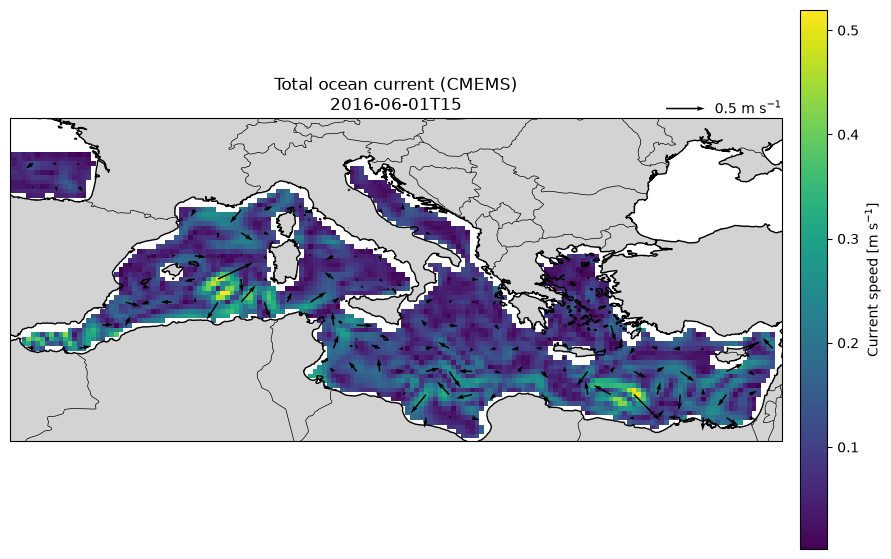

In [9]:

fig, ax = plt.subplots(
    figsize=(12, 7),
    subplot_kw={"projection": ccrs.PlateCarree()}
)

# Plot speed as background
pcm = ax.pcolormesh(
    ds_t.lon,
    ds_t.lat,
    speed,
    cmap="viridis",
    shading="auto",
    transform=ccrs.PlateCarree()
)

# Subsample vectors so arrows do not overlap
step = 5

q = ax.quiver(
    ds_t.lon.values[::step],
    ds_t.lat.values[::step],
    u.values[::step, ::step],
    v.values[::step, ::step],
    transform=ccrs.PlateCarree(),
    scale=10,
    width=0.002,
    color="black"
)

# Reference arrow
ax.quiverkey(
    q,
    X=0.9,
    Y=1.03,
    U=0.5,
    label="0.5 m s$^{-1}$",
    labelpos="E"
)

ax.coastlines(resolution="10m")
ax.add_feature(cfeature.LAND, facecolor="lightgray")
ax.add_feature(cfeature.BORDERS, linewidth=0.5)


# Colorbar
cbar = fig.colorbar(
    pcm,
    ax=ax,
    orientation="vertical",
    pad=0.02
)
cbar.set_label("Current speed [m s$^{-1}$]")

actual_time = np.datetime_as_string(ds_t.time.values, unit="h")

ax.set_title(
    f"Total ocean current (CMEMS)\n{actual_time}"
)

plt.show()